# TP4 - Validation et Cohérence des Données

**Difficulté:** Intermédiaire  
**Dataset:** healthcare_inconsistent.csv  
**Description:** Vérification des contraintes logiques et cohérence inter-colonnes

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('data/healthcare_inconsistent.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 300 lignes × 9 colonnes
 Taille mémoire: 0.08 MB




,patient_id,age,birth_date,email,start_date,end_date,price,postal_code,heart_rate
0,1,42,1920-01-01,wlmit@company.com,2023-01-01,2023-01-05,601.91,3340,35
1,2,24,1920-01-02,invalid-email,2023-01-02,2023-01-06,-95.26,2120,132
2,3,17,1920-01-03,wkimx@company.com,2023-01-03,2023-01-07,4506.44,9691,39
3,4,-5,1920-01-04,krvzm@gmail.com,2023-01-04,2023-01-08,25.55,1138,100
4,5,12,1920-01-05,dzicv@gmail.com,2023-01-05,2023-01-09,968.22,3688,119




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int64  
 2   birth_date   300 non-null    object 
 3   email        300 non-null    object 
 4   start_date   300 non-null    object 
 5   end_date     300 non-null    object 
 6   price        300 non-null    float64
 7   postal_code  300 non-null    int64  
 8   heart_rate   300 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 21.2+ KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

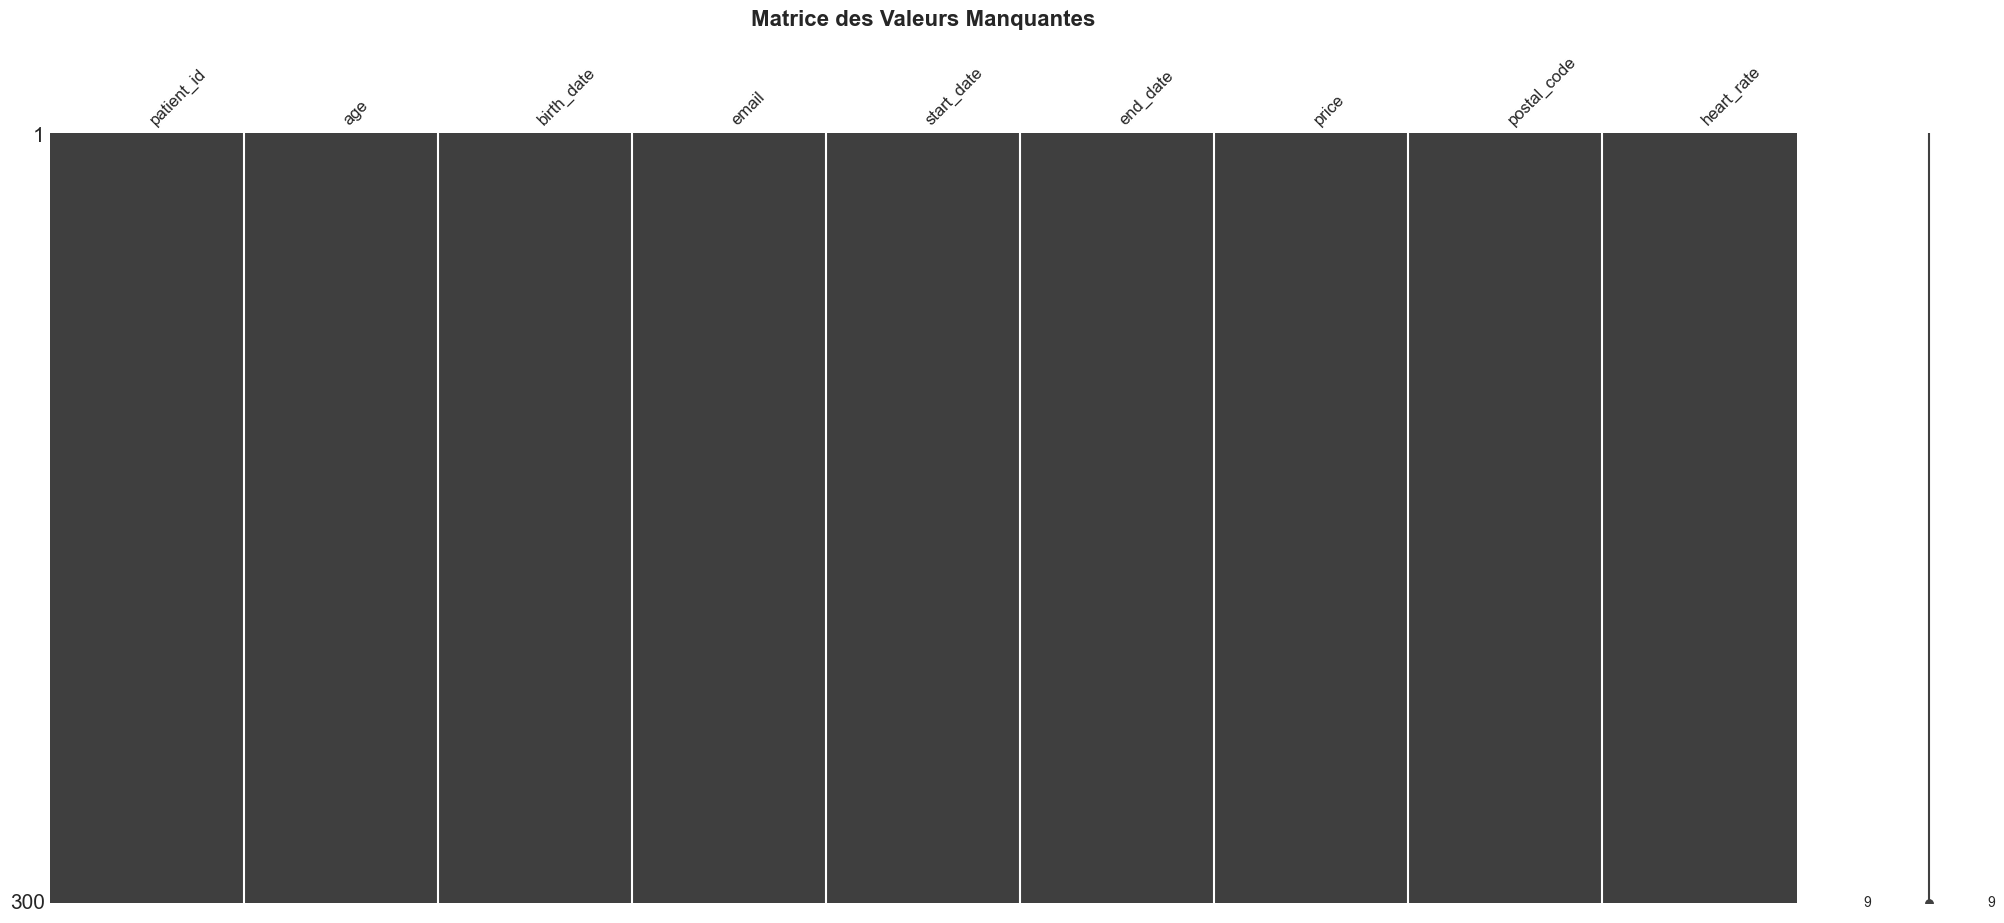


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Y a-t-il des âges négatifs ou supérieurs à 120 ans ?
2. Les dates de fin sont-elles toujours après les dates de début ?
3. Y a-t-il des emails sans '@' ?
4. Les codes postaux respectent-ils le format attendu ?
5. Y a-t-il des incohérences entre l'âge et la date de naissance ?
6. Les prix sont-ils tous positifs ?
7. Y a-t-il des valeurs aberrantes dans les signes vitaux ?
8. Les unités de mesure sont-elles cohérentes ?
9. Combien d'enregistrements violent au moins une contrainte ?
10. Quelle contrainte est la plus souvent violée ?


In [4]:
#  Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions

# Exemple d'analyses:
# df.describe()
# df['colonne'].value_counts()
# df.isnull().sum()
# etc.

print("Réponses aux questions:")
print("="*80)

# Écrivez vos réponses ici

print("1. Nombre de valeurs négatives ou supérieure a 120 dans la colonnne Age")
print(f"Nombre de valeur d'age négatif : {df[df['age'] < 0].shape[0]}")
print(f"Nombre de valeur d'age supérieur a 120 : {df[df['age'] > 120].shape[0]}")

print("-"*80)
print("2. Date de fin précédent date de début ?")
print(f"Date de fin précédent date de début : {df[df['end_date'] < df['start_date']].shape[0]}")

print("-"*80)
print("3. Emails sans @ ?")
print(f"Nombre d'email sans @ : {df[df['email'].str.contains('@') == False].shape[0]}")

print("-"*80)
print("4. Code Postal au bon format ?")
reponse = """
Si l'on s'attend a avoir des Code Postaux au format Francais, aucun n'est bon; il manque 1 chiffres; a priori le 0.
Le soucis vient du dataset qui a des CP en int et non en string ce qui provoque un soucis sur le premier 0 qui saute.
Dans notre cas le soucis existe dès le fichier source.
"""
print(reponse)

print("-"*80)
print("5. Incohérence entre age et date_naissance ?")
print(f"Nombre d'incohérence entre age et date_naissance : {df[df['age'] != (pd.to_datetime(df['start_date']).dt.year - pd.to_datetime(df['birth_date']).dt.year)].shape[0]}")

print("-"*80)
print("6. Prix tous positifs ?")
print(f"Nombre de prix négatifs : {df[df['price'] < 0].shape[0]}")

print("-"*80)
print("7. Valeurs abhérentes dans les signes vitaux [heart_rate] ?")
display(df['heart_rate'].describe())
reponse = """
On est sur des valeurs de battements par minute entre 30 et 249, ce qui semble cohérent a première vue,
Mais il existe un consensus pour dire que le bpm max est de 220 - age. On aurait donc des valeurs relativement haute.
A 240 on est en tachychardie.
"""
print(reponse)

print("-"*80)
print("8. Cohérences des unités de mesures ?")
reponse = """
On a des valeurs de heart_rate en bpm ce qui est cohérent par rapport a l'usage.
De meme que les ages semblent etre en années.
Les prix ont beaucoup de chiffres apres la virgules
"""
print(reponse)

print("-"*80)
print("9. Nombre d'enregistrements violent au moins une contrainte ?")
df_invalid = df[(df['age'] < 0)
                 | (df['age'] > 120) 
                 | (df['email'].str.contains('@') == False) 
                 | (df['age'] != (pd.to_datetime(df['start_date']).dt.year - pd.to_datetime(df['birth_date']).dt.year)) 
                 | (df['price'] < 0)]
print(df_invalid.shape[0])

print("-"*80)
print("10. Contrainte la moins respectée")
reponse = """
La contrainte la moins respectée est celle sur l'age par rapport a la date de naissance
"""
print(reponse)

Réponses aux questions:
1. Nombre de valeurs négatives ou supérieure a 120 dans la colonnne Age
Nombre de valeur d'age négatif : 10
Nombre de valeur d'age supérieur a 120 : 0
--------------------------------------------------------------------------------
2. Date de fin précédent date de début ?
Date de fin précédent date de début : 5
--------------------------------------------------------------------------------
3. Emails sans @ ?
Nombre d'email sans @ : 8
--------------------------------------------------------------------------------
4. Code Postal au bon format ?

Si l'on s'attend a avoir des Code Postaux au format Francais, aucun n'est bon; il manque 1 chiffres; a priori le 0.
Le soucis vient du dataset qui a des CP en int et non en string ce qui provoque un soucis sur le premier 0 qui saute.
Dans notre cas le soucis existe dès le fichier source.

--------------------------------------------------------------------------------
5. Incohérence entre age et date_naissance ?
Nombre d

count   300.00
mean    136.68
std      62.92
min      30.00
25%      79.75
50%     137.00
75%     186.00
max     249.00
Name: heart_rate, dtype: float64


On est sur des valeurs de battements par minute entre 30 et 249, ce qui semble cohérent a première vue,
Mais il existe un consensus pour dire que le bpm max est de 220 - age. On aurait donc des valeurs relativement haute.
A 240 on est en tachychardie.

--------------------------------------------------------------------------------
8. Cohérences des unités de mesures ?

On a des valeurs de heart_rate en bpm ce qui est cohérent par rapport a l'usage.
De meme que les ages semblent etre en années.
Les prix ont beaucoup de chiffres apres la virgules

--------------------------------------------------------------------------------
9. Nombre d'enregistrements violent au moins une contrainte ?
298
--------------------------------------------------------------------------------
10. Contrainte la moins respectée

La contrainte la moins respectée est celle sur l'age par rapport a la date de naissance



## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Définir un dictionnaire de contraintes de validation
### Étape 2: Créer une fonction validate_constraints(df)
### Étape 3: Valider les plages numériques (âge, prix, etc.) -> Faire les transfo nécéssaire a la validation
### Étape 4: Valider les formats (email, téléphone, code postal) -> Faire les transfo nécéssaire a la validation
### Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance) -> Faire les transfo nécéssaire a la validation
### Étape 6: Créer des indicateurs pour chaque violation
### Étape 7: Décider des actions correctives pour chaque type
### Étape 8: Appliquer les corrections
### Étape 9: Standardiser les unités de mesure
### Étape 10: Générer un rapport de validation complet


In [5]:
# ========================================
# Étape 1: Définir un dictionnaire de contraintes de validation
# ========================================

# TODO Dico a revoir car il utilise le df initial et pas le final
dico_verif = {
    "age":  (df["age"].between(0,120)), # Age compris entre 0 et 120
    "dates" : (df["end_date"] > df["start_date"]), # Date de sortie ultérieure a la date d'entrée
    "email" : (df["email"].str.contains("@")), # Présence d'un @ dans l'adresse mail
    "prix" : (df["price"] > 0), # Prix positif
    "date_naissance" :  (df["age"] == (pd.to_datetime(df["start_date"]).dt.year - pd.to_datetime(df["birth_date"]).dt.year)), # Vérification de l'age par rapport a la date de naissance
    "bpm" : (df["heart_rate"].between(50, 220 - df["age"])), # Vérification du rythme cardiaque selon la contrainte BPM Max = 220 - Age, avec un BPM min a 50
    "code_postal" : (df["postal_code"].between(1000, 9999)) # Vérification du code postal copris entre 1000 et 9999
}

# Vérification
print(f" Étape 1 complétée")

 Étape 1 complétée


In [6]:
# ========================================
# Étape 2: Créer une fonction validate_constraints(df)
# ========================================

def validate_constraints(df: pd.DataFrame) -> bool:
    """Validation d'un DataFrame (df) en fonction d'un dictionnaire de contraintes"""
    # Dictionnaire des contraintes a appliquer (remis a l'intérieur de la fonction pour que ce soit bien sur le bon df)
    dico_verif = {
        "age":  (df["age"].between(0,120)), # Age compris entre 0 et 120
        "dates" : (df["end_date"] > df["start_date"]), # Date de sortie ultérieure a la date d'entrée
        "email" : (df["email"].str.contains("@")), # Présence d'un @ dans l'adresse mail
        "prix" : (df["price"] > 0), # Prix positif
        "date_naissance" :  (df["age"] == (pd.to_datetime(df["start_date"]).dt.year - pd.to_datetime(df["birth_date"]).dt.year)), # Vérification de l'age par rapport a la date de naissance
        "bpm" : (df["heart_rate"].between(50, 220 - df["age"])), # Vérification du rythme cardiaque selon la contrainte BPM Max = 220 - Age, avec un BPM min a 50
        "code_postal" : (df["postal_code"].between(1000, 9999)) # Vérification du code postal
    }
    # Initialisation de la validation globale
    validate = True
    # Test de chaque contrainte
    for contrainte, condition in dico_verif.items():
        if len(df[condition]) == len(df):
            print(f"La contrainte {contrainte} est respectée")
        else:
            print(f"La contrainte {contrainte} n'est pas respectée : {len(df[~condition])} valeurs incorrectes")
            validate = False # Si ube des conditions n'est pas respecté, on invalide tout le df
    return validate

validate_constraints(df)

# Vérification
print(f" Étape 2 complétée")

La contrainte age n'est pas respectée : 10 valeurs incorrectes
La contrainte dates n'est pas respectée : 5 valeurs incorrectes
La contrainte email n'est pas respectée : 8 valeurs incorrectes
La contrainte prix n'est pas respectée : 6 valeurs incorrectes
La contrainte date_naissance n'est pas respectée : 298 valeurs incorrectes
La contrainte bpm n'est pas respectée : 151 valeurs incorrectes
La contrainte code_postal est respectée
 Étape 2 complétée


In [7]:
# ========================================
# Étape 3: Valider les plages numériques (âge, prix, etc.)
# ========================================

# Création du dataframe de travail 
df_clean = df.copy()

# Transformations nécéssaire a la validation pour les valeur numériques : Age, Prix

# Correction des valeurs négatives par la valeur absolue, 
# je part du principe que la valeur négative est une erreur d'entrée et non une abération a supprimer
df_clean['age'] = df_clean['age'].abs()
df_clean['price'] = df_clean['price'].abs()

# Capping de l'age entre 0 et 120
df_clean['age'] = df_clean['age'].clip(lower=0, upper=120)

# Correction du BPM selon un mini a 50 et un maximum basé sur l'age (consensus a 220-age)
df_clean['heart_rate'] = df_clean['heart_rate'].clip(lower=50, upper=(220-df_clean['age']))

validate_constraints(df_clean)

# Vérification
print(f" Étape 3 complétée")

La contrainte age est respectée
La contrainte dates n'est pas respectée : 5 valeurs incorrectes
La contrainte email n'est pas respectée : 8 valeurs incorrectes
La contrainte prix est respectée
La contrainte date_naissance n'est pas respectée : 298 valeurs incorrectes
La contrainte bpm est respectée
La contrainte code_postal est respectée
 Étape 3 complétée


In [17]:
# ========================================
# Étape 4: Valider les formats (email, téléphone, code postal)
# ========================================

# Remplacement de tout les emails invalide par l'adresse invalid@email.com, qui est facilement trouvable dans le dataset
df_clean['email'].loc[df["email"].str.contains("@") == False] = "invalid@email.com"

validate_constraints(df_clean)

# Vérification
print(f" Étape 4 complétée")

La contrainte age est respectée
La contrainte dates n'est pas respectée : 5 valeurs incorrectes
La contrainte email est respectée
La contrainte prix est respectée
La contrainte date_naissance est respectée
La contrainte bpm est respectée
La contrainte code_postal est respectée
 Étape 4 complétée


In [20]:
# ========================================
# Étape 5: Vérifier la cohérence inter-colonnes (dates, âge/date_naissance)
# ========================================
 
def calcul_birthdate(age, date_ref):
    """Calcul de la date d'anniversaire a partir de l'age et d'une date de référence"""
    # Différentiel en jour entre la date de référence et l'age * 365 jours
    birth_date = pd.to_datetime(date_ref) - pd.to_timedelta(age * 365, unit='D')
    # Retourne un string formaté au format du dataframe initial (que la date)
    return birth_date.strftime('%Y-%m-%d')

# Application de la fonction de calcul pour appliquer une date de naissance plus cohérente
df_clean['birth_date'] = df_clean.apply(lambda row: calcul_birthdate(row['age'], row['start_date']), axis=1)

# Correction des dates de début et de fin inversée par réinversion de celles-ci
# récupération des indesx des lignes a modifier
df_to_change = df_clean[~dico_verif['dates']].index
# pour chaque index, on inverse les dates de début et de fin
for index in df_to_change:
    start_date = df_clean.loc[index, 'start_date'] # recup de la date de début initiale
    end_date = df_clean.loc[index, 'end_date'] # récup de la date de fin initiale
    # Inversion des dates aux index concernés
    df_clean.loc[index, 'start_date'] = end_date
    df_clean.loc[index, 'end_date'] = start_date

# Test des contraintes aprés modification
validate_constraints(df_clean)

# Vérification
print(f" Étape 5 complétée")

La contrainte age est respectée
La contrainte dates est respectée
La contrainte email est respectée
La contrainte prix est respectée
La contrainte date_naissance est respectée
La contrainte bpm est respectée
La contrainte code_postal est respectée
 Étape 5 complétée


In [21]:
# ========================================
# Étape 6: Créer des indicateurs pour chaque violation
# ========================================

reponse = """
La fonction de validation des contraintes donne le nombre de violation pour chacune des contraintes.
"""
print(reponse)

# Vérification
print(f" Étape 6 complétée")


La fonction de validation des contraintes donne le nombre de violation pour chacune des contraintes.

 Étape 6 complétée


In [22]:
# ========================================
# Étape 7: Décider des actions correctives pour chaque type
# ========================================

reponse = """
Résumé des corrections par contrainte
Price : Valeur absolue
Age : Valeur absolue et capping entre 0 et 120
Heart_Rate : Capping entre 50 et 220 - Age
Email : remplacement par invalide@email.com
Birth_date : Recalcul via le start_date et l'age
Start_Date / End_date : Inversion des deux valeurs
"""

print(reponse)

# Vérification
print(f" Étape 7 complétée")


Résumé des corrections par contrainte
Price : Valeur absolue
Age : Valeur absolue et capping entre 0 et 120
Heart_Rate : Capping entre 50 et 220 - Age
Email : remplacement par invalide@email.com
Birth_date : Recalcul via le start_date et l'age
Start_Date / End_date : Inversion des deux valeurs

 Étape 7 complétée


In [ ]:
# ========================================
# Étape 8: Appliquer les corrections
# ========================================

reponse = """"
Les corrections ont été faites aux étapes 3 a 5.
"""

print(reponse)

# Vérification
print(f" Étape 8 complétée")

"
Les corrections ont été faites aux étapes 3 a 6

 Étape 8 complétée


In [13]:
# ========================================
# Étape 9: Standardiser les unités de mesure
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 9 complétée")

 Étape 9 complétée


In [14]:
# ========================================
# Étape 10: Générer un rapport de validation complet
# ========================================

# TODO: Écrivez votre code ici


# Vérification
print(f" Étape 10 complétée")

 Étape 10 complétée


## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [24]:
transformations = ["Price : Valeur absolue",
"Age : Valeur absolue et capping entre 0 et 120",
"Heart_Rate : Capping entre 50 et 220 - Age",
"Email : remplacement par invalide@email.com",
"Birth_date : Recalcul via le start_date et l'age",
"Start_Date / End_date : Inversion des deux valeurs"]

In [25]:
# Rapport de nettoyage
rapport = {
    'Dimensions_initiales': df.shape,
    'Dimensions_finales': df_clean.shape,  # À mettre à jour avec df_clean
    'Lignes_supprimées': df.shape[0] - df_clean.shape[0],
    'Colonnes_supprimées': df.shape[1] - df_clean.shape[1],
    'Valeurs_manquantes_traitées': df.isna().sum().sum() - df_clean.isna().sum().sum(),
    'Doublons_supprimés': df.duplicated().sum() - df_clean.duplicated().sum(),
    'Outliers_traités': 0,
    'Transformations_appliquées': transformations
}

print("=" * 80)
print(" " * 25 + " RAPPORT DE NETTOYAGE")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès!")

                          RAPPORT DE NETTOYAGE
Dimensions_initiales.................... (300, 9)
Dimensions_finales...................... (300, 9)
Lignes_supprimées....................... 0
Colonnes_supprimées..................... 0
Valeurs_manquantes_traitées............. 0
Doublons_supprimés...................... 0
Outliers_traités........................ 0
Transformations_appliquées.............. ['Price : Valeur absolue', 'Age : Valeur absolue et capping entre 0 et 120', 'Heart_Rate : Capping entre 50 et 220 - Age', 'Email : remplacement par invalide@email.com', "Birth_date : Recalcul via le start_date et l'age", 'Start_Date / End_date : Inversion des deux valeurs']

 TP terminé avec succès!
